In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Resize
import numpy as np
from PIL import Image

def preprocess_images(image_paths):
  images=[]
  for path in image_paths:
    try:
      img=Image.open(path)
      img=img.resize((224,224))
      img=np.array(img)
      images.append(img)
    except:
      pass
  return np.array(images)


X_real = preprocess_images(real_images)
X_fake = preprocess_images(fake_images)
print("Real shape:", X_real.shape)
print("Fake shape:", X_fake.shape)

Real shape: (745, 224, 224, 3)
Fake shape: (250, 224, 224, 3)


In [ ]:
#Normalisation
X_real=X_real/255
X_fake=X_fake/255

#creation des label
y_real=np.zeros(len(X_real))
y_fake=np.ones(len(X_fake))

#Combiner datasets
X=np.concatenate((X_real,X_fake),axis=0)
y=np.concatenate((y_real,y_fake),axis=0)

In [ ]:
import numpy as np
base = "/content/drive/MyDrive/fake-image-project/results"

np.save(base + "/X.npy", X)
np.save(base + "/y.npy", y)

NameError: name 'X' is not defined

In [ ]:
import numpy as np

base = "/content/drive/MyDrive/fake-image-project/results"

X = np.load(base + "/X.npy")
y = np.load(base + "/y.npy")

print(X.shape, y.shape)

(995, 224, 224, 3) (995,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models

In [ ]:
model = models.Sequential([
    layers.Input(shape=(224,224,3)),  # ✅ ici

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - accuracy: 0.7437 - loss: 0.6390 - val_accuracy: 0.7688 - val_loss: 0.5407
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 142s 4s/step - accuracy: 0.7437 - loss: 0.5720 - val_accuracy: 0.7688 - val_loss: 0.5423
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 101s 4s/step - accuracy: 0.7437 - loss: 0.5730 - val_accuracy: 0.7688 - val_loss: 0.5476
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 137s 4s/step - accuracy: 0.7437 - loss: 0.5767 - val_accuracy: 0.7688 - val_loss: 0.5437
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 157s 5s/step - accuracy: 0.7437 - loss: 0.5715 - val_accuracy: 0.7688 - val_loss: 0.5442


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7688 - loss: 0.5442
Test Accuracy: 0.7688442468643188
Test Loss: 0.5442454814910889


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 4.png to 4.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Prediction value: 0.036229253
Real Image ✅


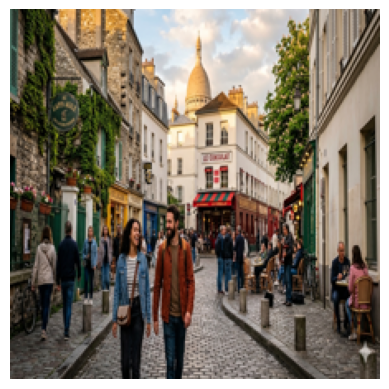

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Charger l'image
image_path = "4.png"
img = Image.open(image_path).convert("RGB")  # important

# 2️⃣ Resize
img = img.resize((224, 224))

# 3️⃣ Convertir + normaliser
img_array = np.array(img) / 255.0

# 4️⃣ Ajouter dimension (batch)
img_array = np.expand_dims(img_array, axis=0)

# 5️⃣ Prédiction
prediction = model.predict(img_array)

# 6️⃣ Affichage (sans erreur)
plt.imshow(img)
plt.axis('off')

# 7️⃣ Résultat
print("Prediction value:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Fake Image ❌")
else:
    print("Real Image ✅")